In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [3]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (920, 16)

Columns:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [9]:
# Convert the target into binary classification
df["target"] = (df["num"] > 0).astype(int)

# Check the result
df["target"].value_counts()

,count
target,
1,509
0,411


In [10]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [11]:
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Remove columns that should not be used as prediction features
X = df.drop(["target", "num", "id", "dataset"], axis=1)
y = df["target"]

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

In [17]:
# Numerical data preprocessing
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical data preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing methods
preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 736
Testing samples: 184


In [18]:
# Logistic Regression model

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
# Make predictions on the test data
y_pred_lr = logistic_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Results")
print("--------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression Results
--------------------------
Accuracy : 0.842391304347826
Precision: 0.8411214953271028
Recall   : 0.8823529411764706
F1 Score : 0.861244019138756


In [20]:
# Decision Tree model

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

# Train the model
decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [21]:
# Make predictions
y_pred_dt = decision_tree.predict(X_test)

# Evaluate the model
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.7717391304347826
Precision: 0.7941176470588235
Recall   : 0.7941176470588235
F1 Score : 0.7941176470588235


In [22]:
# Random Forest model

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# Train the model
random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
# Make predictions
y_pred_rf = random_forest.predict(X_test)

# Evaluate the model
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.8586956521739131
Precision: 0.8584905660377359
Recall   : 0.8921568627450981
F1 Score : 0.875


In [24]:
# Compare all three models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.842391,0.841121,0.882353,0.861244
1,Decision Tree,0.771739,0.794118,0.794118,0.794118
2,Random Forest,0.858696,0.858491,0.892157,0.875000


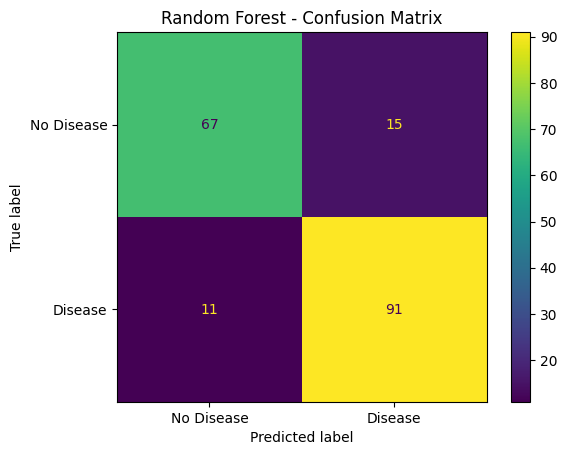

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [26]:
# Confusion matrices for all three models

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Logistic Regression")
print(cm_lr)
print("False Negatives:", cm_lr[1, 0])

print("\nDecision Tree")
print(cm_dt)
print("False Negatives:", cm_dt[1, 0])

print("\nRandom Forest")
print(cm_rf)
print("False Negatives:", cm_rf[1, 0])

Logistic Regression
[[65 17]
 [12 90]]
False Negatives: 12

Decision Tree
[[61 21]
 [21 81]]
False Negatives: 21

Random Forest
[[67 15]
 [11 91]]
False Negatives: 11


In [27]:
# Get probability of disease
rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

# Change the classification threshold
threshold = 0.40

# Make predictions using the new threshold
y_pred_rf_040 = (rf_probabilities >= threshold).astype(int)

# Confusion matrix
cm_rf_040 = confusion_matrix(y_test, y_pred_rf_040)

print("Random Forest with threshold =", threshold)
print(cm_rf_040)

print("\nFalse Negatives:", cm_rf_040[1, 0])
print("False Positives:", cm_rf_040[0, 1])
print("Recall:", recall_score(y_test, y_pred_rf_040))
print("Precision:", precision_score(y_test, y_pred_rf_040))

Random Forest with threshold = 0.4
[[57 25]
 [ 5 97]]

False Negatives: 5
False Positives: 25
Recall: 0.9509803921568627
Precision: 0.7950819672131147


## Threshold Selection

The default threshold of 0.50 produced 11 false negatives.
Because false negatives are more costly in a disease-screening
scenario, a lower threshold of 0.40 was evaluated.

At a threshold of 0.40, the number of false negatives decreased
from 11 to 5, while recall increased to approximately 95.1%.

The trade-off is an increase in false positives from 15 to 25.
In this screening context, accepting additional false positives
is preferable to missing patients who may have the disease.

Therefore, a threshold of 0.40 was selected for this project.

This threshold is intended for this educational model and should
not be interpreted as a clinically validated threshold.

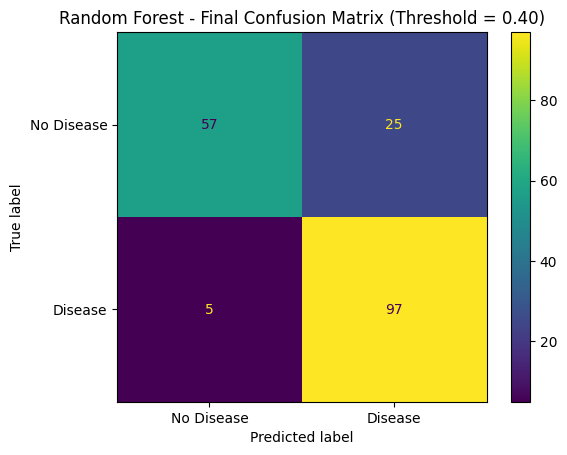

In [28]:
# Final confusion matrix using threshold 0.40

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_040,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("Random Forest - Final Confusion Matrix (Threshold = 0.40)")
plt.show()

In [29]:
# Calculate ROC-AUC for all three models

auc_lr = roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1])
auc_dt = roc_auc_score(y_test, decision_tree.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, random_forest.predict_proba(X_test)[:, 1])

print("ROC-AUC Scores")
print("----------------")
print("Logistic Regression:", round(auc_lr, 3))
print("Decision Tree      :", round(auc_dt, 3))
print("Random Forest      :", round(auc_rf, 3))

ROC-AUC Scores
----------------
Logistic Regression: 0.904
Decision Tree      : 0.827
Random Forest      : 0.925


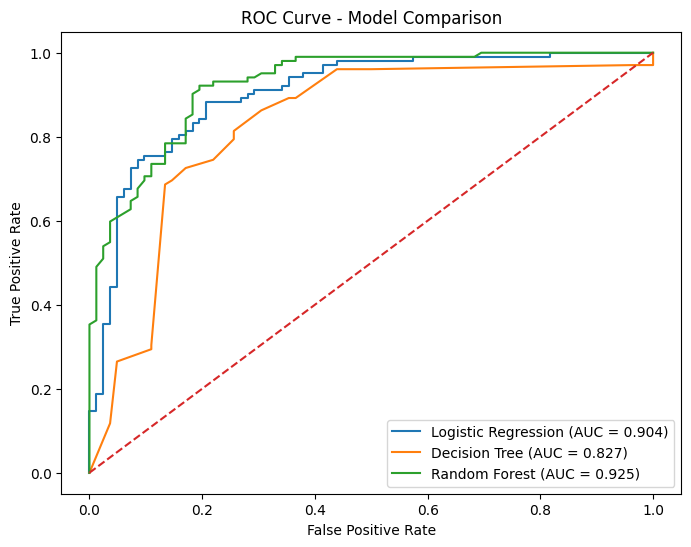

In [30]:
# ROC Curve for all three models

lr_prob = logistic_model.predict_proba(X_test)[:, 1]
dt_prob = decision_tree.predict_proba(X_test)[:, 1]
rf_prob = random_forest.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.show()

In [31]:
# Final comparison of all models

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest (0.50)",
        "Random Forest (0.40)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_040)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_040)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_040)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_040)
    ],
    "False Negatives": [
        cm_lr[1, 0],
        cm_dt[1, 0],
        cm_rf[1, 0],
        cm_rf_040[1, 0]
    ]
})

final_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,False Negatives
0,Logistic Regression,0.842,0.841,0.882,0.861,12
1,Decision Tree,0.772,0.794,0.794,0.794,21
2,Random Forest (0.50),0.859,0.858,0.892,0.875,11
3,Random Forest (0.40),0.837,0.795,0.951,0.866,5


## Final Results and Model Decision

Three classification algorithms were compared: Logistic Regression,
Decision Tree, and Random Forest.

Random Forest achieved the highest ROC-AUC of 0.925, compared with
0.904 for Logistic Regression and 0.827 for Decision Tree.

At the default threshold of 0.50, Random Forest produced 11 false
negatives. Since false negatives are more costly in a disease-screening
scenario, the threshold was reduced to 0.40.

At the 0.40 threshold, Random Forest produced only 5 false negatives
and achieved a recall of approximately 95.1%. Although false positives
increased from 15 to 25, this trade-off is acceptable for a screening
scenario where missing a potentially diseased patient is more costly.

Therefore, Random Forest with a classification threshold of 0.40 was
selected as the final model for this project.

## Clinical Interpretation of the Confusion Matrix

The final Random Forest confusion matrix at a threshold of 0.40 was:

- True Negatives (TN): 57
- False Positives (FP): 25
- False Negatives (FN): 5
- True Positives (TP): 97

True positives represent patients correctly identified as having
heart disease, while true negatives represent patients correctly
identified as not having heart disease.

False negatives are patients who have the disease but were predicted
as not having it. In a screening context, these errors are especially
important because they represent potentially missed cases.

False positives represent patients without the disease who were
flagged as potentially having it. These may lead to additional
evaluation, but are considered less costly than missing a potentially
diseased patient in this project.

## Limitations

- This project uses a relatively limited dataset and may not represent
  all patient populations.
- The model was evaluated on the available dataset and may perform
  differently on new or external data.
- The selected threshold of 0.40 is not clinically validated.
- The model should not be used to diagnose disease.
- The model should not replace a qualified medical professional.
- Predictions may be affected by missing data, data quality, and
  differences between the training population and real-world patients.
- Further validation on larger and diverse clinical datasets would be
  required before considering any real-world clinical application.

## Conclusion

This project demonstrates how machine learning can be used to estimate
the likelihood of heart disease from structured medical data.

Three classification algorithms were compared fairly. Random Forest
performed best overall, achieving a ROC-AUC of 0.925.

Because false negatives are more costly in a disease-screening
scenario, the classification threshold was deliberately reduced from
0.50 to 0.40. This reduced false negatives from 11 to 5 and increased
recall to approximately 95.1%.

The final model is intended only as an educational machine learning
demonstration and is not a medical diagnostic tool.

## Final Results and Model Decision

Three classification algorithms were compared: Logistic Regression,
Decision Tree, and Random Forest.

Random Forest achieved the highest ROC-AUC of 0.925, compared with
0.904 for Logistic Regression and 0.827 for Decision Tree.

At the default threshold of 0.50, Random Forest produced 11 false
negatives. Since false negatives are more costly in a disease-screening
scenario, the threshold was reduced to 0.40.

At the 0.40 threshold, Random Forest produced only 5 false negatives
and achieved a recall of approximately 95.1%. Although false positives
increased from 15 to 25, this trade-off is acceptable for a screening
scenario where missing a potentially diseased patient is more costly.

Therefore, Random Forest with a classification threshold of 0.40 was
selected as the final model for this project.

## Clinical Interpretation of the Confusion Matrix

The final Random Forest confusion matrix at a threshold of 0.40 was:

- True Negatives (TN): 57
- False Positives (FP): 25
- False Negatives (FN): 5
- True Positives (TP): 97

True positives represent patients correctly identified as having
heart disease, while true negatives represent patients correctly
identified as not having heart disease.

False negatives are patients who have the disease but were predicted
as not having it. In a screening context, these errors are especially
important because they represent potentially missed cases.

False positives represent patients without the disease who were
flagged as potentially having it. These may lead to additional
evaluation, but are considered less costly than missing a potentially
diseased patient in this project.